# Notebook 03 — Embeddings (a mágica acontece aqui)

## Objetivo de aprendizado

Entender como um rosto vira **um vetor numérico de 128 dimensões** e por que **distâncias entre esses vetores** dizem se duas fotos são da mesma pessoa.

Este é o **núcleo** do reconhecimento facial moderno.

## Resumo da intuição

Imagine que cada rosto vira um **ponto num espaço de 128 dimensões**. O modelo (FaceNet, ArcFace, etc.) foi treinado de forma que:

- Pontos de **fotos da mesma pessoa** ficam **próximos** uns dos outros.
- Pontos de **pessoas diferentes** ficam **longe**.

Reconhecer alguém = **medir distância** entre o vetor da câmera ao vivo e os vetores cadastrados. Menor distância = mais provável que seja a pessoa.

Não há "classe" de cada pessoa hard-coded no modelo. O modelo aprendeu a **geometria** de rostos. Por isso ele funciona pra pessoas que ele nunca viu durante o treino.

## Conceitos novos

- **Embedding** (ou *encoding*, ou *feature vector*): representação numérica de um objeto (no nosso caso, um rosto) num espaço vetorial.
- **Triplet loss**: função de perda usada pra treinar FaceNet — pega tripletes (âncora, mesma pessoa, outra pessoa) e força "mesma pessoa" a ficar mais perto que "outra pessoa".
- **Distância euclidiana**: `‖a − b‖₂ = sqrt(Σ (aᵢ − bᵢ)²)`. Métrica padrão pra comparar embeddings normalizados.
- **PCA (Principal Component Analysis)**: técnica que projeta vetores de alta dimensão (128-D) em poucas dimensões (2-D) preservando o máximo de variância — pra você poder **ver** os clusters num gráfico.

## 1. Setup e geração de embeddings das suas fotos

In [1]:
from pathlib import Path

import face_recognition
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_DIR = Path('../dataset')
pessoas = sorted([p for p in DATASET_DIR.iterdir() if p.is_dir()])
print('Pessoas no dataset:')
for p in pessoas:
    fotos = sorted(list(p.glob('*.jp*g')) + list(p.glob('*.png')))
    print(f'  {p.name}: {len(fotos)} fotos')

/home/diogo/Coding/AILAB-FACIAL/.venv/lib/python3.13/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Pessoas no dataset:
  diogo: 8 fotos


> ⚠️ **Esta primeira parte só funciona bem se você tiver mais de 1 pessoa.** Se só tem `dataset/diogo/`, os exercícios de "distância entre pessoas diferentes" não vão produzir comparações úteis. Você pode:
> 1. Pedir 5 fotos pra 1-2 colegas (com consentimento — `docs/PRIVACIDADE.md`).
> 2. Ou baixar o dataset público **LFW** (Labeled Faces in the Wild).
>
> O notebook usa o que estiver disponível e degrada com aviso.

In [2]:
def gerar_embeddings(dataset_dir):
    """Percorre dataset/<pessoa>/*.jpg e devolve DataFrame com nome, arquivo, embedding."""
    registros = []
    for pessoa_dir in sorted(dataset_dir.iterdir()):
        if not pessoa_dir.is_dir():
            continue
        for f in sorted(list(pessoa_dir.glob('*.jp*g')) + list(pessoa_dir.glob('*.png'))):
            img = face_recognition.load_image_file(f)
            locs = face_recognition.face_locations(img, model='hog')
            if not locs:
                print(f'  ✗ sem rosto: {f.name}')
                continue
            enc = face_recognition.face_encodings(img, locs)[0]
            registros.append({'pessoa': pessoa_dir.name, 'arquivo': f.name, 'embedding': enc})
    return pd.DataFrame(registros)

df = gerar_embeddings(DATASET_DIR)
print(f'\nTotal de embeddings: {len(df)}')
print(df.groupby('pessoa').size())
if len(df):
    print('\nShape do primeiro embedding:', df.iloc[0]['embedding'].shape)

  ✗ sem rosto: WhatsApp Image 2026-06-09 at 10.59.31 (2).jpeg


  ✗ sem rosto: WhatsApp Image 2026-06-09 at 10.59.32 (2).jpeg


  ✗ sem rosto: WhatsApp Image 2026-06-09 at 10.59.32 (3).jpeg



Total de embeddings: 5
pessoa
diogo    5
dtype: int64

Shape do primeiro embedding: (128,)


## 2. Os 128 números — vamos olhar pra eles

Cada embedding é um vetor de 128 números (entre ~-0.3 e ~0.3 tipicamente). Esses números, sozinhos, **não significam nada** pra um humano. São coordenadas num espaço aprendido. Só comparando vetores que tiramos sentido.

Primeiros 10 valores de até 3 embeddings:
  diogo           WhatsApp Image 2026-  [-0.043  0.05  -0.019 -0.01   0.028 -0.036 -0.025 -0.037  0.145 -0.076]
  diogo           WhatsApp Image 2026-  [-0.054  0.059  0.023 -0.059 -0.093  0.032 -0.028  0.021  0.156 -0.083]
  diogo           WhatsApp Image 2026-  [-0.039  0.106  0.005 -0.023 -0.085 -0.    -0.054 -0.057  0.146 -0.051]


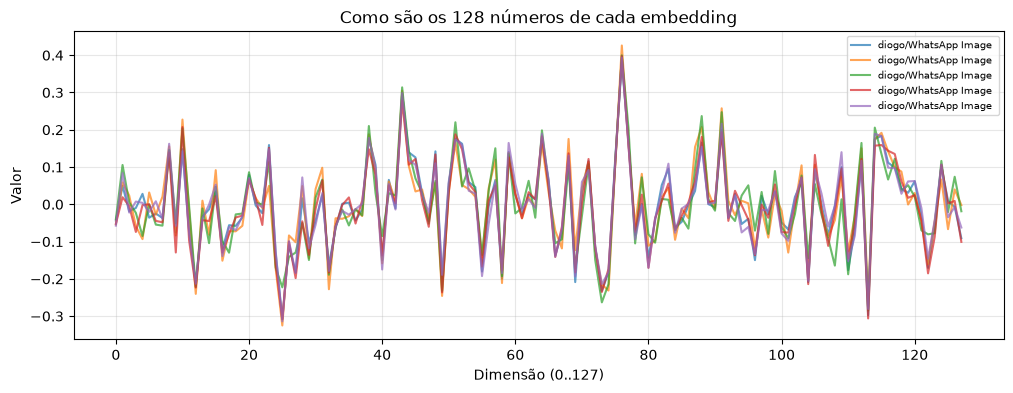

In [3]:
print('Primeiros 10 valores de até 3 embeddings:')
for i in range(min(3, len(df))):
    e = df.iloc[i]['embedding']
    print(f"  {df.iloc[i]['pessoa']:15s} {df.iloc[i]['arquivo'][:20]:20s}  {e[:10].round(3)}")

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(min(5, len(df))):
    ax.plot(df.iloc[i]['embedding'], alpha=0.7,
            label=f"{df.iloc[i]['pessoa']}/{df.iloc[i]['arquivo'][:15]}")
ax.set_xlabel('Dimensão (0..127)')
ax.set_ylabel('Valor')
ax.set_title('Como são os 128 números de cada embedding')
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.3)
plt.show()

## 3. Distâncias — o que tudo isso significa na prática

Vamos calcular a **matriz de distância** entre todos os pares de fotos. Esperamos ver:

- **Bloco diagonal pequeno** (mesma pessoa entre si): distâncias **baixas**.
- **Blocos off-diagonais grandes** (pessoa A vs pessoa B): distâncias **altas**.

Threshold de referência do `face_recognition`: **0.6**. Distância < 0.6 → mesma pessoa.

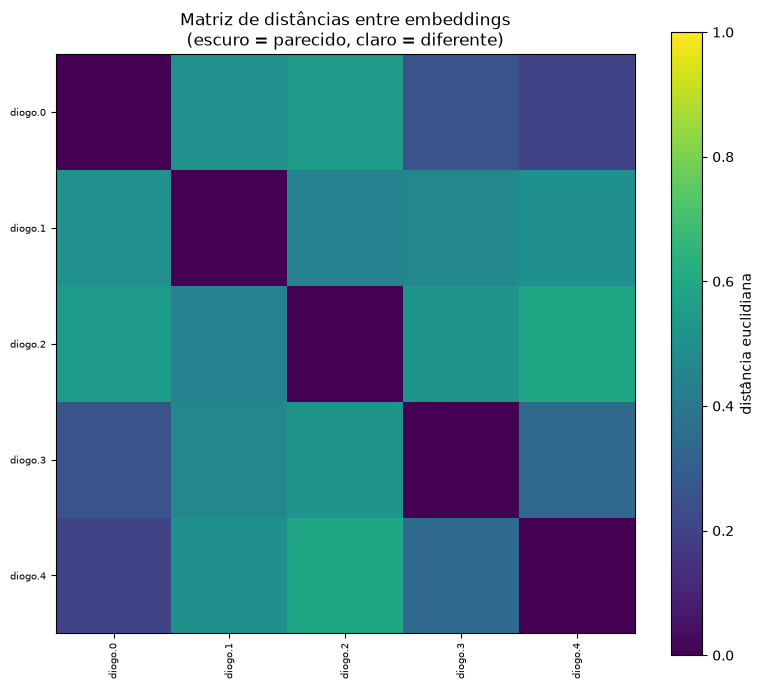

In [4]:
embeddings = np.stack(df['embedding'].values)
rotulos = df['pessoa'].values
n = len(embeddings)

dist = np.linalg.norm(embeddings[:, None, :] - embeddings[None, :, :], axis=-1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(dist, cmap='viridis', vmin=0, vmax=1.0)
ax.set_xticks(range(n))
ax.set_xticklabels([f'{r[:8]}.{i}' for i, r in enumerate(rotulos)], rotation=90, fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels([f'{r[:8]}.{i}' for i, r in enumerate(rotulos)], fontsize=7)
ax.set_title('Matriz de distâncias entre embeddings\n(escuro = parecido, claro = diferente)')
plt.colorbar(im, ax=ax, label='distância euclidiana')
plt.tight_layout(); plt.show()

## 4. Distribuição: mesma pessoa vs pessoas diferentes

Este é **o** gráfico de ciência de dados deste projeto. Separamos:

- **Pares positivos**: 2 fotos da mesma pessoa.
- **Pares negativos**: 2 fotos de pessoas diferentes.

E plotamos a distribuição das distâncias de cada grupo. Se as duas distribuições estão **bem separadas**, existe um threshold claro. Se elas se sobrepõem muito, vai ter erro.

Pares positivos (mesma pessoa): 10
  média=0.437  min=0.205  max=0.586
Pares negativos (pessoas diferentes): 0


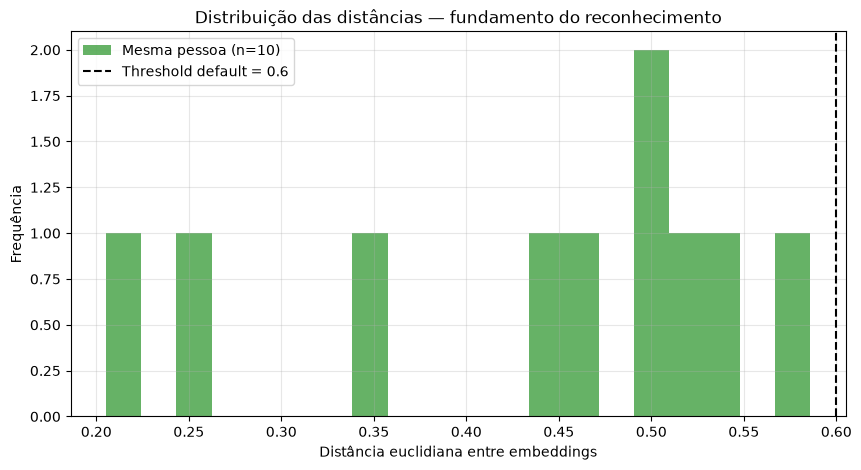

In [5]:
from itertools import combinations

positivos, negativos = [], []
for i, j in combinations(range(n), 2):
    d = dist[i, j]
    if rotulos[i] == rotulos[j]:
        positivos.append(d)
    else:
        negativos.append(d)

print(f'Pares positivos (mesma pessoa): {len(positivos)}')
if positivos:
    print(f'  média={np.mean(positivos):.3f}  min={np.min(positivos):.3f}  max={np.max(positivos):.3f}')
print(f'Pares negativos (pessoas diferentes): {len(negativos)}')
if negativos:
    print(f'  média={np.mean(negativos):.3f}  min={np.min(negativos):.3f}  max={np.max(negativos):.3f}')

fig, ax = plt.subplots(figsize=(10, 5))
if positivos:
    ax.hist(positivos, bins=20, alpha=0.6, label=f'Mesma pessoa (n={len(positivos)})', color='green')
if negativos:
    ax.hist(negativos, bins=20, alpha=0.6, label=f'Pessoas diferentes (n={len(negativos)})', color='red')
ax.axvline(0.6, color='black', linestyle='--', label='Threshold default = 0.6')
ax.set_xlabel('Distância euclidiana entre embeddings')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição das distâncias — fundamento do reconhecimento')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 🔎 Como ler esse gráfico

- Verde à **esquerda** (distâncias baixas) e vermelho à **direita** (distâncias altas) = modelo está separando bem.
- Se houver **sobreposição** entre verde e vermelho, é zona de risco. Qualquer threshold ali vai cometer erros.
- O threshold 0.6 (padrão) corta as duas distribuições onde houver menor overlap.

No próximo notebook, vamos **escolher** o threshold formalmente medindo FAR e FRR.

## 5. Visualização em 2D com PCA

Os embeddings vivem em 128-D — impossível visualizar. **PCA** projeta em 2-D preservando o máximo de variância. Se as pessoas formam **clusters separados** no gráfico 2-D, o modelo está fazendo bem o trabalho dele.

In [6]:
from sklearn.decomposition import PCA

if len(set(rotulos)) >= 2 and len(embeddings) >= 3:
    pca = PCA(n_components=2)
    pts = pca.fit_transform(embeddings)
    print(f'Variância explicada pelos 2 primeiros componentes: '
          f'{pca.explained_variance_ratio_.sum()*100:.1f}%')

    fig, ax = plt.subplots(figsize=(8, 6))
    for nome in sorted(set(rotulos)):
        mask = rotulos == nome
        ax.scatter(pts[mask, 0], pts[mask, 1], label=nome, s=120, alpha=0.7, edgecolors='black')
    ax.legend()
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title('Embeddings projetados em 2D (PCA)')
    ax.grid(alpha=0.3)
    plt.show()
else:
    print('Só 1 pessoa no dataset — PCA não vai mostrar separação.')
    print('Adicione fotos de mais 1-2 pessoas e rode novamente.')

Só 1 pessoa no dataset — PCA não vai mostrar separação.
Adicione fotos de mais 1-2 pessoas e rode novamente.


## 6. Para anotar em `notebooks/duvidas.md`

1. A média das distâncias "mesma pessoa" é menor que a média "pessoas diferentes"? Em quanto?
2. Existe **sobreposição** entre as duas distribuições no histograma?
3. No gráfico PCA, suas fotos formam um cluster compacto separado dos colegas?
4. Por que **não conseguimos** entender o que cada uma das 128 dimensões significa? (dica: o modelo aprendeu sozinho, ninguém disse "dimensão 7 = espessura do nariz")

## 7. Próximo notebook

`04_threshold_evaluation.ipynb` — Calcular formalmente **FAR (False Acceptance Rate)** e **FRR (False Rejection Rate)** pra cada threshold, escolher o **EER (Equal Error Rate)** e justificar. **Esse é o entregável de ciência de dados** do trabalho de extensão.
